In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic_2d
import time

In [19]:
from scipy.stats import binned_statistic_2d
import time
   

def parse_obj_sampled(obj_path, sample_size=5000):
    start_time = time.time()
    
    vertices = []
    faces = []
    with open(obj_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            if line.startswith("v "):
                p = line.split()
                vertices.append([float(p[1]), float(p[2]), float(p[3])])

            elif line.startswith("f "):
                face = []
                for t in line.split()[1:]:
                    face.append(int(t.split("/")[0]))  # vertex index only
                faces.append(face)

    V = np.asarray(vertices, dtype=np.float64)

    nverts = len(V)
    nfaces = len(faces)

    def resolve(i):
        return (i - 1) if i > 0 else (nverts + i)

    triangle_normals = []
    triangle_areas = []

    # Randomly sample faces instead of processing all
    if nfaces > sample_size:
        sampled_indices = np.random.choice(nfaces, size=sample_size, replace=False)
        print(f"Randomly sampling {sample_size} faces out of {nfaces} total faces")
    else:
        sampled_indices = range(nfaces)
        print(f"Processing all {nfaces} faces (less than sample size)")

    # progress setup
    next_report = 0
    report_step = max(1, len(sampled_indices) // 20)  # ~5% steps

    for count, fi in enumerate(sampled_indices):
        if count >= next_report:
            pct = 100.0 * count / max(1, len(sampled_indices))
            print(f"processing faces: {pct:5.1f}% ({count}/{len(sampled_indices)})")
            next_report += report_step

        face = faces[fi]
        if len(face) < 3:
            continue

        idx = [resolve(i) for i in face]
        v0 = V[idx[0]]

        for k in range(1, len(idx) - 1):
            v1 = V[idx[k]]
            v2 = V[idx[k + 1]]

            n = np.cross(v1 - v0, v2 - v0)
            nn = np.linalg.norm(n)
            if nn <= 1e-12:
                continue

            triangle_normals.append(n / nn)
            triangle_areas.append(0.5 * nn)

    triangle_normals = np.asarray(triangle_normals, dtype=np.float64)
    triangle_areas = np.asarray(triangle_areas, dtype=np.float64)

    end_time = time.time()
    runtime = end_time - start_time

    # ---- final stats ----
    print(f"OBJ parsing runtime: {runtime:.2f} seconds")



    print(f"processing faces: {100.0:5.1f}% ({len(sampled_indices)}/{len(sampled_indices)})")
    print(f"\nLoaded OBJ: {len(vertices)} vertices")
    print(f"Generated: {len(triangle_normals)} triangle faces from {len(sampled_indices)} sampled faces")
    print(f"Sample size used: {len(sampled_indices)}")

    n = triangle_normals
    a = triangle_areas

    # component ranges (sanity checking they should be normalized already)
    print("  min/max nx:", float(n[:, 0].min()), float(n[:, 0].max()))
    print("  min/max ny:", float(n[:, 1].min()), float(n[:, 1].max()))
    print("  min/max nz:", float(n[:, 2].min()), float(n[:, 2].max()))

    # --- area stats ---
    print("\ntriangle areas:")
    print("  min/mean/max:", float(a.min()), float(a.mean()), float(a.max()))
    print("  total area:", float(a.sum()))

    # dominance
    a_sorted = np.sort(a)
    total_area = float(a_sorted.sum())
    top1 = float(a_sorted[int(0.99 * len(a_sorted)):].sum()) / (total_area + 1e-12)
    top01 = float(a_sorted[int(0.999 * len(a_sorted)):].sum()) / (total_area + 1e-12)
    print(f"  area in top 1% triangles:  {100.0 * top1:.2f}%")
    print(f"  area in top 0.1% triangles:{100.0 * top01:.2f}%")

    # area-weighted mean normal
    m = (n * a[:, None]).sum(axis=0)
    m_norm = np.linalg.norm(m)
    m_unit = m / m_norm
    print("\narea-weighted mean normal:")
    print("  m_unit:", m_unit)
    print("  alignment with +Z (dot):", float(m_unit[2]))

    return triangle_normals, triangle_areas


# this method will take an .obj and return the triangle face normals and areas
def parse_obj(obj_path, z_scale=1.0):

    
    start_time = time.time()

    vertices = []
    faces = []
    with open(obj_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            if line.startswith("v "):
                p = line.split()
                if len(p) >= 4:  # Ensure we have at least 4 elements: 'v', x, y, z
                    vertices.append([float(p[1]), float(p[2]), float(p[3])])
                else:
                    print(f"Warning: Malformed vertex line: '{line}'")

            elif line.startswith("f "):
                face = []
                for t in line.split()[1:]:
                    face.append(int(t.split("/")[0]))  # vertex index only
                faces.append(face)

    V = np.asarray(vertices, dtype=np.float64)

    nverts = len(V)
    nfaces = len(faces)

    def resolve(i):
        return (i - 1) if i > 0 else (nverts + i)

    triangle_normals = []
    triangle_areas = []

    # progress setup
    next_report = 0
    report_step = max(1, nfaces // 20)  # ~5% steps

    for fi, face in enumerate(faces):
        if fi >= next_report:
            pct = 100.0 * fi / max(1, nfaces)
            print(f"processing faces: {pct:5.1f}% ({fi}/{nfaces})")
            next_report += report_step

        if len(face) < 3:
            continue

        idx = [resolve(i) for i in face]
        v0 = V[idx[0]]

        for k in range(1, len(idx) - 1):
            v1 = V[idx[k]]
            v2 = V[idx[k + 1]]

            n = np.cross(v1 - v0, v2 - v0)
            nn = np.linalg.norm(n)
            if nn <= 1e-12:
                continue

            triangle_normals.append(n / nn)
            triangle_areas.append(0.5 * nn)


    triangle_normals = np.asarray(triangle_normals, dtype=np.float64)
    triangle_areas = np.asarray(triangle_areas, dtype=np.float64)

    
    end_time = time.time()
    runtime = end_time - start_time
    print(f"OBJ parsing runtime: {runtime:.2f} seconds")

    # ---- final stats ----
    print(f"processing faces: {100.0:5.1f}% ({nfaces}/{nfaces})")
    print(f"\nLoaded OBJ: {len(vertices)} vertices")
    print(f"Generated: {len(triangle_normals)} triangle faces")

    n = triangle_normals
    a = triangle_areas

    # component ranges (sanity checking they should be normalized already)
    print("  min/max nx:", float(n[:, 0].min()), float(n[:, 0].max()))
    print("  min/max ny:", float(n[:, 1].min()), float(n[:, 1].max()))
    print("  min/max nz:", float(n[:, 2].min()), float(n[:, 2].max()))

    # --- area stats ---
    print("\ntriangle areas:")
    print("  min/mean/max:", float(a.min()), float(a.mean()), float(a.max()))
    print("  total area:", float(a.sum()))

    # dominance
    a_sorted = np.sort(a)
    total_area = float(a_sorted.sum())
    top1 = float(a_sorted[int(0.99 * len(a_sorted)):].sum()) / (total_area + 1e-12)
    top01 = float(a_sorted[int(0.999 * len(a_sorted)):].sum()) / (total_area + 1e-12)
    print(f"  area in top 1% triangles:  {100.0 * top1:.2f}%")
    print(f"  area in top 0.1% triangles:{100.0 * top01:.2f}%")

    # area-weighted mean normal
    m = (n * a[:, None]).sum(axis=0)
    m_norm = np.linalg.norm(m)
    m_unit = m / m_norm
    print("\narea-weighted mean normal:")
    print("  m_unit:", m_unit)
    print("  alignment with +Z (dot):", float(m_unit[2]))

    return triangle_normals, triangle_areas


## Convert normals to NDF x,y coordinates
def normals_to_ndf_xy(n):
    nx = n[:, 0]
    ny = n[:, 1]
    nz = n[:, 2]  # removed abs() since we'll filter negative z values before calling this
    theta = np.arccos(nz)
    phi = np.arctan2(ny, nx)
    x = np.cos(phi) * np.sin(theta)
    y = np.sin(phi) * np.sin(theta)
    return x, y

def create_ndf_histogram_from_obj(face_normals, face_areas, object_path,img, bins=100):
    # Filter out normals with negative z values
    valid_mask = face_normals[:, 2] >= 0
    filtered_normals = face_normals
    filtered_areas = face_areas/sum(face_areas)  # Normalize areas for better visualization
    
    print(f"Filtered {np.sum(~valid_mask)} normals with negative z values")
    print(f"Using {len(filtered_normals)} normals for NDF histogram")
    
    x, y = normals_to_ndf_xy(filtered_normals)
    
    H, xedges, yedges, _ = binned_statistic_2d(
        x, y, 
        values=filtered_areas,
        statistic='sum',
        bins=bins,
        range=[[-1, 1], [-1, 1]]
    )
    
    H = (H - np.nanmin(H)) / (np.nanmax(H) - np.nanmin(H))


    # Create a plot of the NDF histogram with log scale
    plt.figure(figsize=(10, 8))
    # Create subplot with the original image and NDF histogram side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    # i want a 500x500 crop of the center of the image

    img_cropped = img[img.shape[0]//2 - 250:img.shape[0]//2 + 250, img.shape[1]//2 - 250:img.shape[1]//2 + 250] 
    ax1.imshow(img_cropped)
    ax1.set_title(f'Microscope image of {object_path}')
    ax1.axis('off') 

   

    # Display NDF histogram
    # Add small value to avoid log(0) issues
   
    plt.imshow(H, extent=[-1, 1, -1, 1], origin='lower', cmap='viridis')
    plt.colorbar(label='Normalized Area Density')
    plt.xlabel("sin(θ)cos(ϕ)")
    plt.ylabel("sin(θ)sin(ϕ)") 
    plt.title(f'Normal Distribution Function for a {object_path} Surface')
    plt.axis('equal')
    plt.show()

    
    
    return H, xedges, yedges

# NOT IN USE
# NOT IN USE
# NOT IN USE
def smooth(H, sigma=1.2):
    # Create coordinate arrays based on H dimensions
    height, width = H.shape
    x = np.linspace(-1, 1, width)
    y = np.linspace(-1, 1, height)
    Xc, Yc = np.meshgrid(x, y, indexing="ij")
    
    # Create disk mask
    disk = (Xc * Xc + Yc * Yc) <= 1.0
    
    # Apply Gaussian smoothing
    H_num = gaussian_filter(H * disk, sigma=sigma, mode="constant", cval=0.0)
    H_den = gaussian_filter(disk.astype(np.float64), sigma=sigma, mode="constant", cval=0.0)
    H_smooth = np.where(H_den > 1e-12, H_num / H_den, 0.0)
    
    return H_smooth

processing faces:   0.0% (0/32768)
processing faces:   5.0% (1638/32768)
processing faces:  10.0% (3276/32768)
processing faces:  15.0% (4914/32768)
processing faces:  20.0% (6552/32768)
processing faces:  25.0% (8190/32768)
processing faces:  30.0% (9828/32768)
processing faces:  35.0% (11466/32768)
processing faces:  40.0% (13104/32768)
processing faces:  45.0% (14742/32768)
processing faces:  50.0% (16380/32768)
processing faces:  55.0% (18018/32768)
processing faces:  60.0% (19656/32768)
processing faces:  65.0% (21294/32768)
processing faces:  70.0% (22932/32768)
processing faces:  75.0% (24570/32768)
processing faces:  80.0% (26208/32768)
processing faces:  85.0% (27846/32768)
processing faces:  90.0% (29484/32768)
processing faces:  95.0% (31122/32768)
processing faces: 100.0% (32760/32768)
OBJ parsing runtime: 0.68 seconds
processing faces: 100.0% (32768/32768)

Loaded OBJ: 16641 vertices
Generated: 32768 triangle faces
  min/max nx: -0.9125875660162936 0.9106164704912962
  min

<Figure size 1000x800 with 0 Axes>

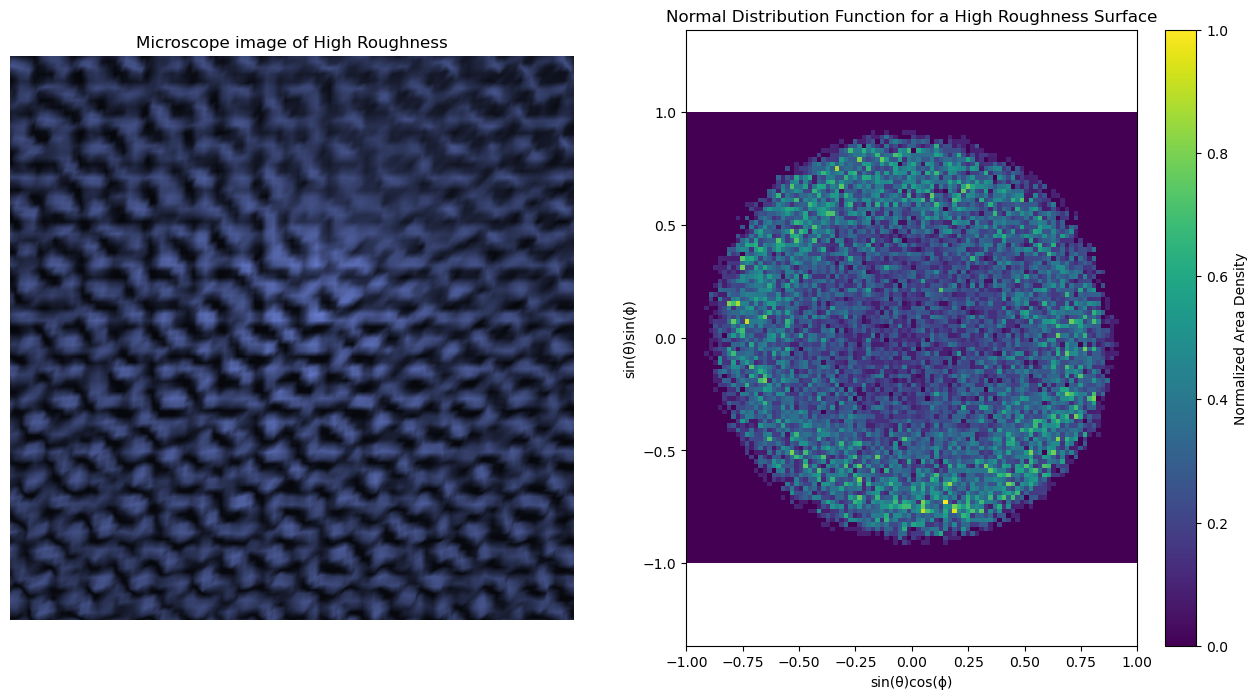

processing faces:   0.0% (0/32768)
processing faces:   5.0% (1638/32768)
processing faces:  10.0% (3276/32768)
processing faces:  15.0% (4914/32768)
processing faces:  20.0% (6552/32768)
processing faces:  25.0% (8190/32768)
processing faces:  30.0% (9828/32768)
processing faces:  35.0% (11466/32768)
processing faces:  40.0% (13104/32768)
processing faces:  45.0% (14742/32768)
processing faces:  50.0% (16380/32768)
processing faces:  55.0% (18018/32768)
processing faces:  60.0% (19656/32768)
processing faces:  65.0% (21294/32768)
processing faces:  70.0% (22932/32768)
processing faces:  75.0% (24570/32768)
processing faces:  80.0% (26208/32768)
processing faces:  85.0% (27846/32768)
processing faces:  90.0% (29484/32768)
processing faces:  95.0% (31122/32768)
processing faces: 100.0% (32760/32768)
OBJ parsing runtime: 0.66 seconds
processing faces: 100.0% (32768/32768)

Loaded OBJ: 16641 vertices
Generated: 32768 triangle faces
  min/max nx: -0.40203996568482475 0.41596479628897526
  m

<Figure size 1000x800 with 0 Axes>

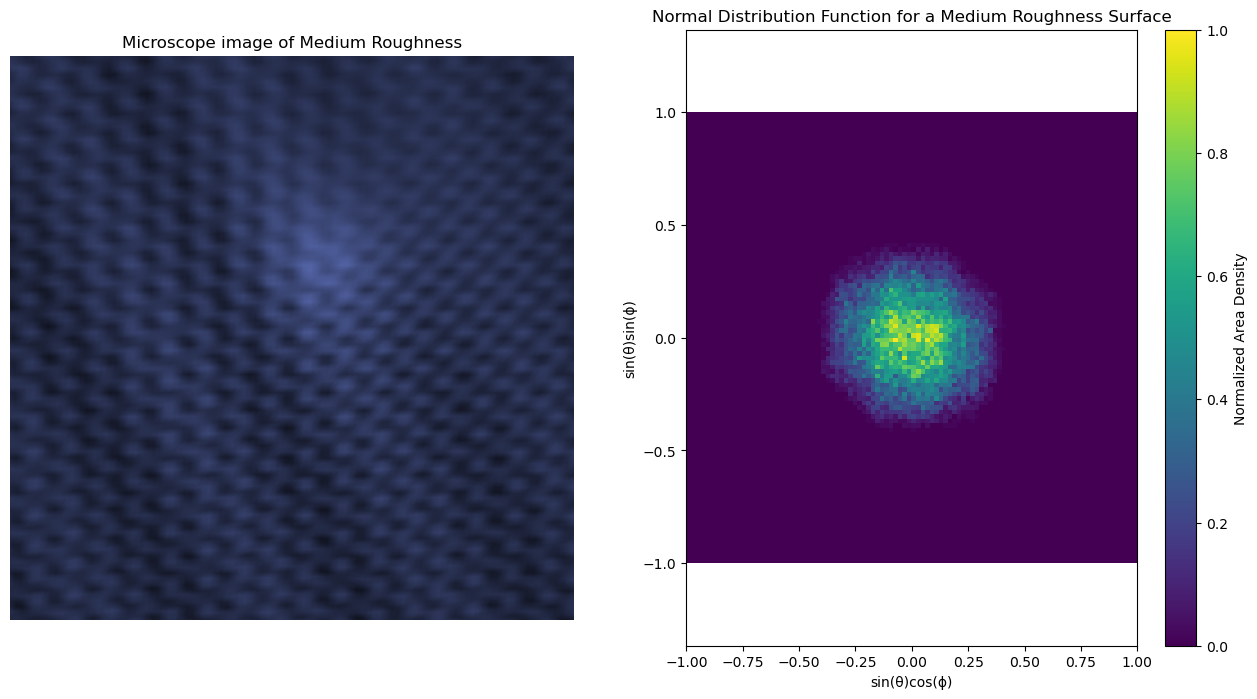

processing faces:   0.0% (0/32768)
processing faces:   5.0% (1638/32768)
processing faces:  10.0% (3276/32768)
processing faces:  15.0% (4914/32768)
processing faces:  20.0% (6552/32768)
processing faces:  25.0% (8190/32768)
processing faces:  30.0% (9828/32768)
processing faces:  35.0% (11466/32768)
processing faces:  40.0% (13104/32768)
processing faces:  45.0% (14742/32768)
processing faces:  50.0% (16380/32768)
processing faces:  55.0% (18018/32768)
processing faces:  60.0% (19656/32768)
processing faces:  65.0% (21294/32768)
processing faces:  70.0% (22932/32768)
processing faces:  75.0% (24570/32768)
processing faces:  80.0% (26208/32768)
processing faces:  85.0% (27846/32768)
processing faces:  90.0% (29484/32768)
processing faces:  95.0% (31122/32768)
processing faces: 100.0% (32760/32768)
OBJ parsing runtime: 0.68 seconds
processing faces: 100.0% (32768/32768)

Loaded OBJ: 16641 vertices
Generated: 32768 triangle faces
  min/max nx: -0.18558407674658434 0.2042995653514904
  mi

<Figure size 1000x800 with 0 Axes>

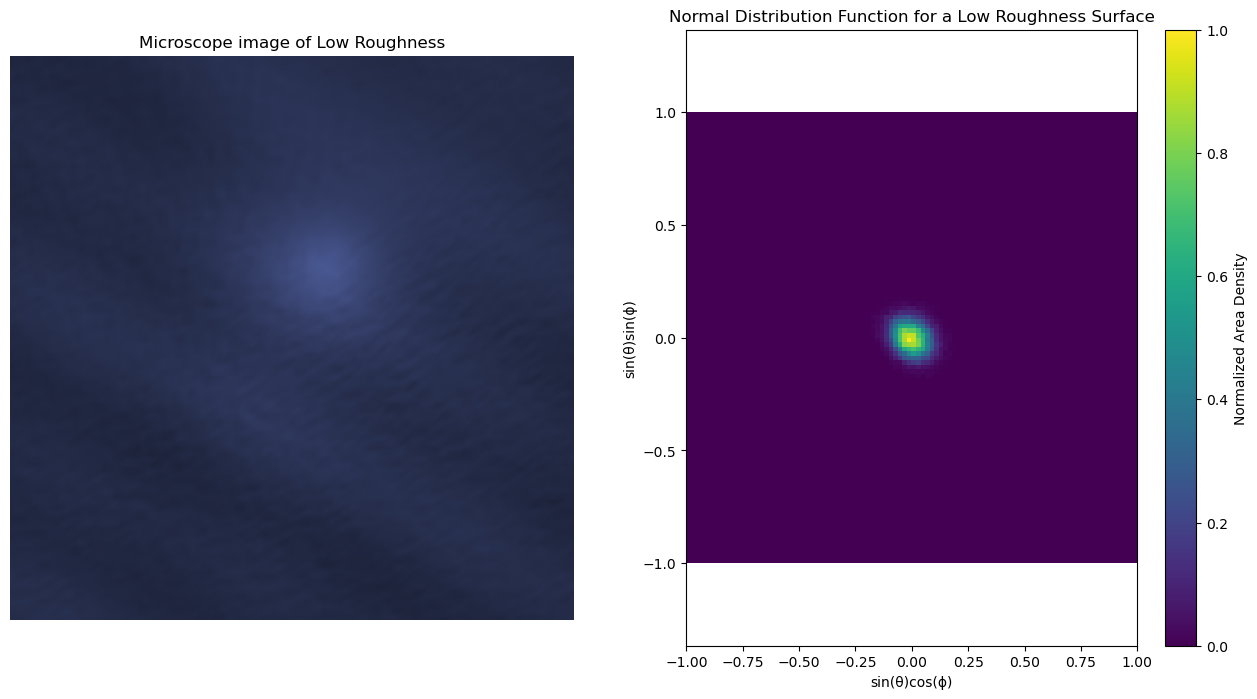

processing faces:   0.0% (0/32768)
processing faces:   5.0% (1638/32768)
processing faces:  10.0% (3276/32768)
processing faces:  15.0% (4914/32768)
processing faces:  20.0% (6552/32768)
processing faces:  25.0% (8190/32768)
processing faces:  30.0% (9828/32768)
processing faces:  35.0% (11466/32768)
processing faces:  40.0% (13104/32768)
processing faces:  45.0% (14742/32768)
processing faces:  50.0% (16380/32768)
processing faces:  55.0% (18018/32768)
processing faces:  60.0% (19656/32768)
processing faces:  65.0% (21294/32768)
processing faces:  70.0% (22932/32768)
processing faces:  75.0% (24570/32768)
processing faces:  80.0% (26208/32768)
processing faces:  85.0% (27846/32768)
processing faces:  90.0% (29484/32768)
processing faces:  95.0% (31122/32768)
processing faces: 100.0% (32760/32768)
OBJ parsing runtime: 0.68 seconds
processing faces: 100.0% (32768/32768)

Loaded OBJ: 16641 vertices
Generated: 32768 triangle faces
  min/max nx: -0.029049338479025095 0.03237861667071265
  

<Figure size 1000x800 with 0 Axes>

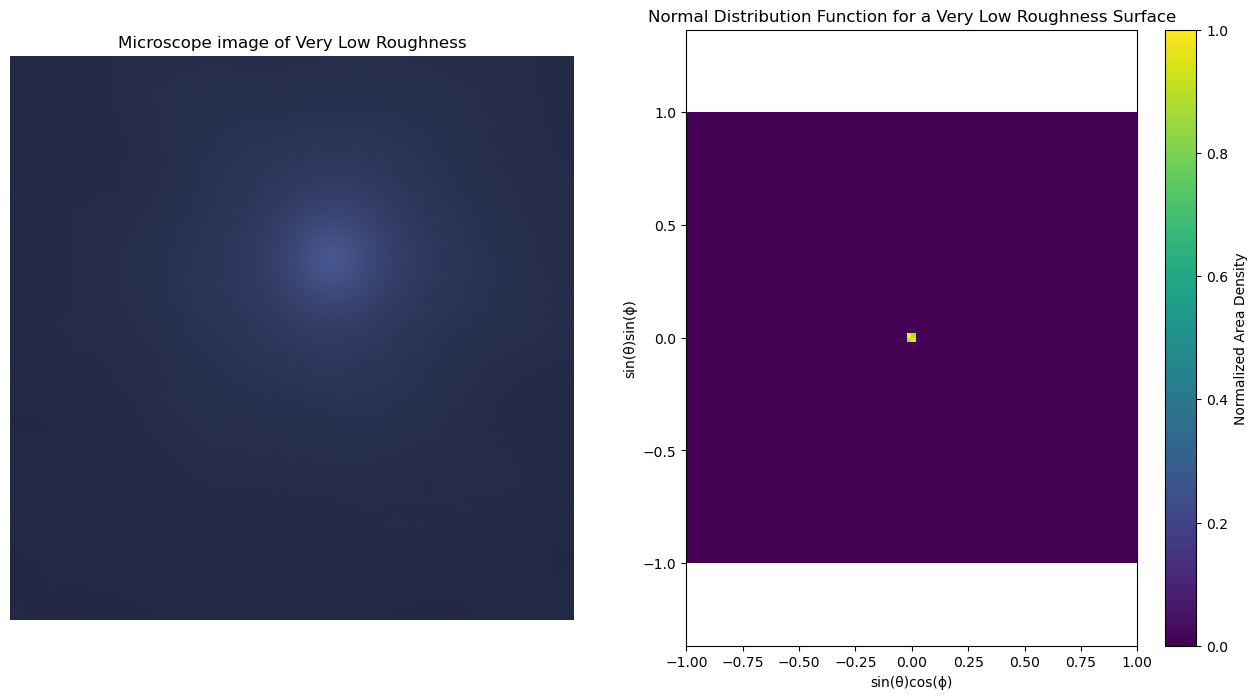

In [20]:
surfaces=[8,9,10,11]
surface_names=["High Roughness", "Medium Roughness", "Low Roughness", "Very Low Roughness"]

for surface in surfaces:
    OBJ_PATH = f"surface_{surface}.obj"  
    img = plt.imread(f"wavetype_{surface}.png")  # Load corresponding 

    triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
    H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, surface_names[surfaces.index(surface)], img)

Randomly sampling 5000 faces out of 32768 total faces
processing faces:   0.0% (0/5000)
processing faces:   5.0% (250/5000)
processing faces:  10.0% (500/5000)
processing faces:  15.0% (750/5000)
processing faces:  20.0% (1000/5000)
processing faces:  25.0% (1250/5000)
processing faces:  30.0% (1500/5000)
processing faces:  35.0% (1750/5000)
processing faces:  40.0% (2000/5000)
processing faces:  45.0% (2250/5000)
processing faces:  50.0% (2500/5000)
processing faces:  55.0% (2750/5000)
processing faces:  60.0% (3000/5000)
processing faces:  65.0% (3250/5000)
processing faces:  70.0% (3500/5000)
processing faces:  75.0% (3750/5000)
processing faces:  80.0% (4000/5000)
processing faces:  85.0% (4250/5000)
processing faces:  90.0% (4500/5000)
processing faces:  95.0% (4750/5000)
OBJ parsing runtime: 0.14 seconds
processing faces: 100.0% (5000/5000)

Loaded OBJ: 16641 vertices
Generated: 5000 triangle faces from 5000 sampled faces
Sample size used: 5000
  min/max nx: -0.90744368072669 0.9

<Figure size 1000x800 with 0 Axes>

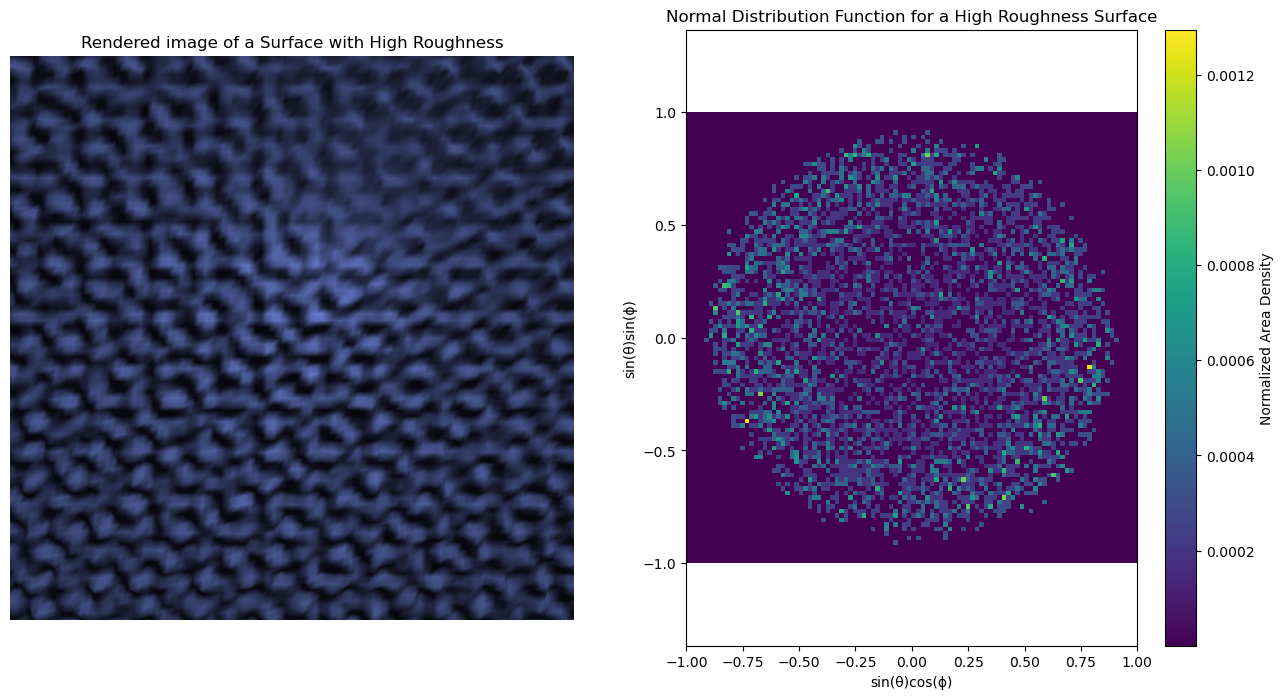

Randomly sampling 5000 faces out of 32768 total faces
processing faces:   0.0% (0/5000)
processing faces:   5.0% (250/5000)
processing faces:  10.0% (500/5000)
processing faces:  15.0% (750/5000)
processing faces:  20.0% (1000/5000)
processing faces:  25.0% (1250/5000)
processing faces:  30.0% (1500/5000)
processing faces:  35.0% (1750/5000)
processing faces:  40.0% (2000/5000)
processing faces:  45.0% (2250/5000)
processing faces:  50.0% (2500/5000)
processing faces:  55.0% (2750/5000)
processing faces:  60.0% (3000/5000)
processing faces:  65.0% (3250/5000)
processing faces:  70.0% (3500/5000)
processing faces:  75.0% (3750/5000)
processing faces:  80.0% (4000/5000)
processing faces:  85.0% (4250/5000)
processing faces:  90.0% (4500/5000)
processing faces:  95.0% (4750/5000)
OBJ parsing runtime: 0.15 seconds
processing faces: 100.0% (5000/5000)

Loaded OBJ: 16641 vertices
Generated: 5000 triangle faces from 5000 sampled faces
Sample size used: 5000
  min/max nx: -0.38708050146441847 

<Figure size 1000x800 with 0 Axes>

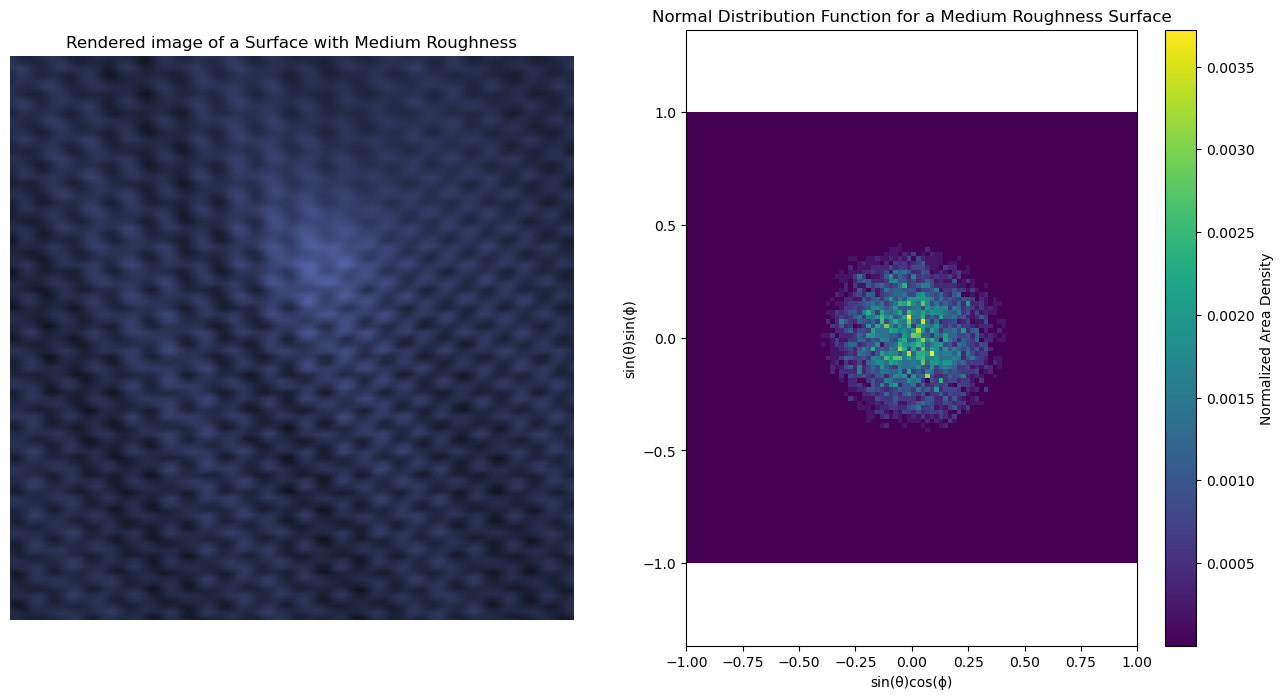

Randomly sampling 5000 faces out of 32768 total faces
processing faces:   0.0% (0/5000)
processing faces:   5.0% (250/5000)
processing faces:  10.0% (500/5000)
processing faces:  15.0% (750/5000)
processing faces:  20.0% (1000/5000)
processing faces:  25.0% (1250/5000)
processing faces:  30.0% (1500/5000)
processing faces:  35.0% (1750/5000)
processing faces:  40.0% (2000/5000)
processing faces:  45.0% (2250/5000)
processing faces:  50.0% (2500/5000)
processing faces:  55.0% (2750/5000)
processing faces:  60.0% (3000/5000)
processing faces:  65.0% (3250/5000)
processing faces:  70.0% (3500/5000)
processing faces:  75.0% (3750/5000)
processing faces:  80.0% (4000/5000)
processing faces:  85.0% (4250/5000)
processing faces:  90.0% (4500/5000)
processing faces:  95.0% (4750/5000)
OBJ parsing runtime: 0.14 seconds
processing faces: 100.0% (5000/5000)

Loaded OBJ: 16641 vertices
Generated: 5000 triangle faces from 5000 sampled faces
Sample size used: 5000
  min/max nx: -0.1670638997321556 0

<Figure size 1000x800 with 0 Axes>

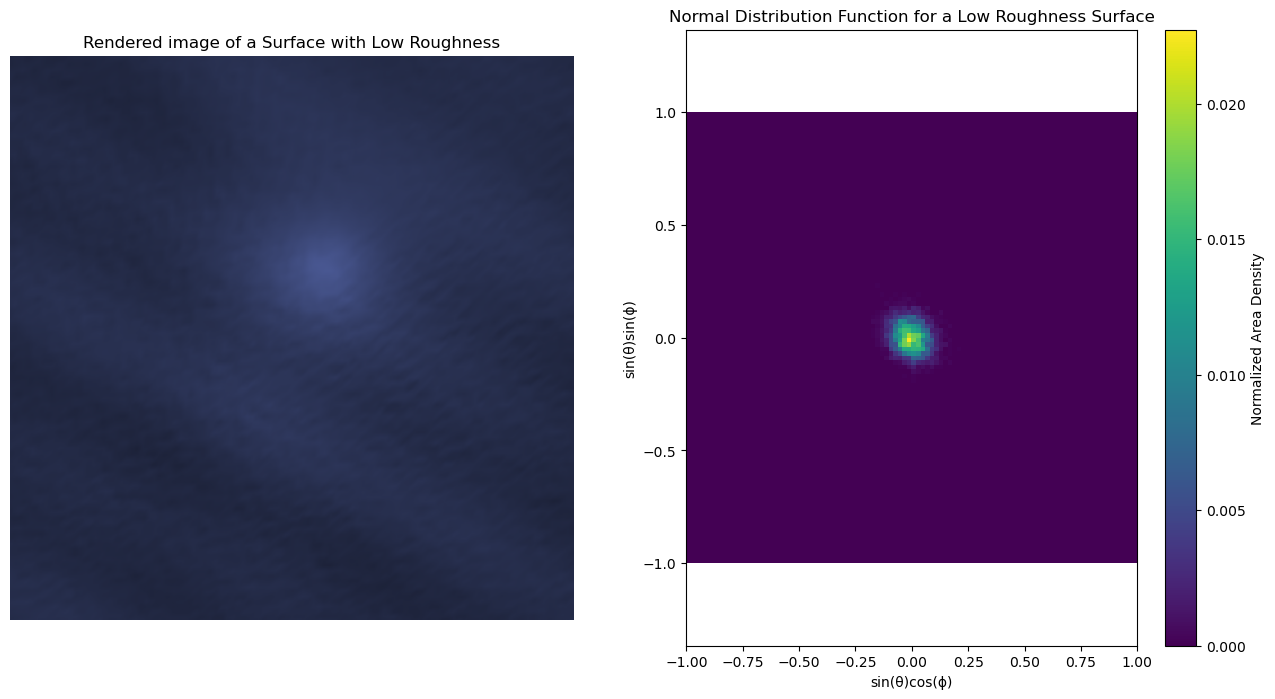

Randomly sampling 5000 faces out of 32768 total faces
processing faces:   0.0% (0/5000)
processing faces:   5.0% (250/5000)
processing faces:  10.0% (500/5000)
processing faces:  15.0% (750/5000)
processing faces:  20.0% (1000/5000)
processing faces:  25.0% (1250/5000)
processing faces:  30.0% (1500/5000)
processing faces:  35.0% (1750/5000)
processing faces:  40.0% (2000/5000)
processing faces:  45.0% (2250/5000)
processing faces:  50.0% (2500/5000)
processing faces:  55.0% (2750/5000)
processing faces:  60.0% (3000/5000)
processing faces:  65.0% (3250/5000)
processing faces:  70.0% (3500/5000)
processing faces:  75.0% (3750/5000)
processing faces:  80.0% (4000/5000)
processing faces:  85.0% (4250/5000)
processing faces:  90.0% (4500/5000)
processing faces:  95.0% (4750/5000)
OBJ parsing runtime: 0.15 seconds
processing faces: 100.0% (5000/5000)

Loaded OBJ: 16641 vertices
Generated: 5000 triangle faces from 5000 sampled faces
Sample size used: 5000
  min/max nx: -0.029049338479025095

<Figure size 1000x800 with 0 Axes>

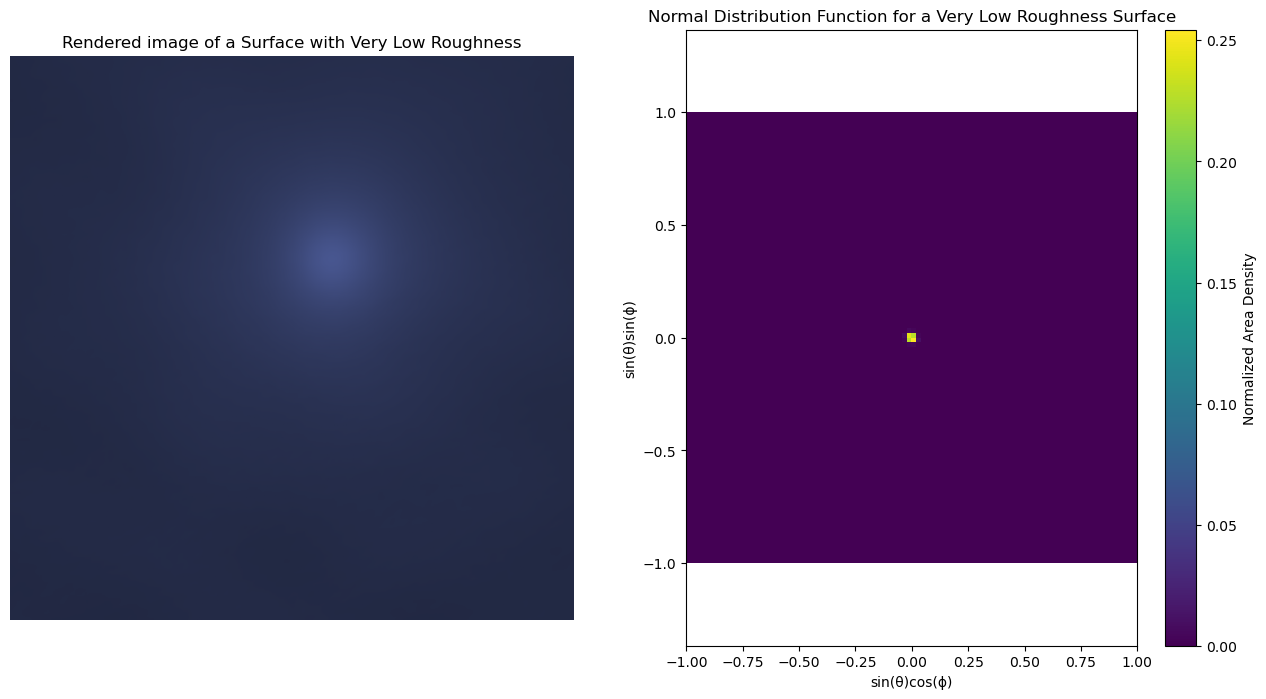

In [ ]:
for surface in surfaces:
    OBJ_PATH = f"surface_{surface}.obj"  
    img = plt.imread(f"wavetype_{surface}.png")  # Load corresponding image
    triangle_normals, triangle_areas = parse_obj_sampled(OBJ_PATH)
    H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, surface_names[surfaces.index(surface)], img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 61.09 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

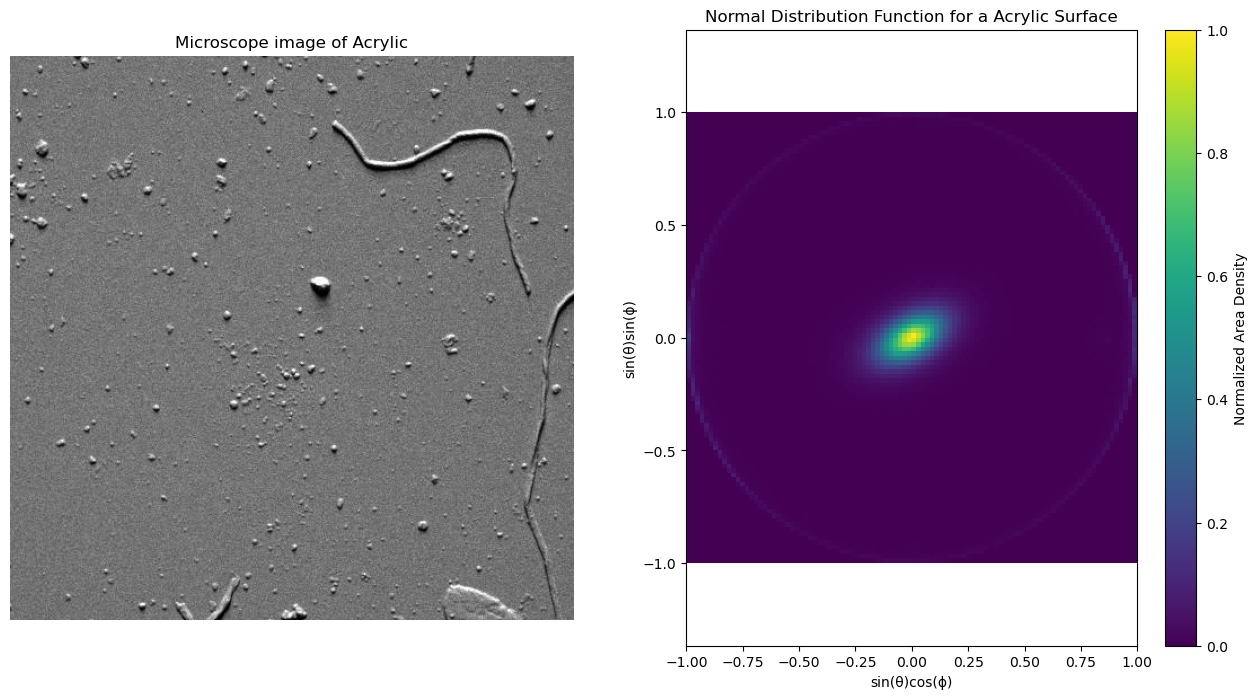

In [21]:
OBJ_PATH = "acrylic.obj"  
img = plt.imread(f"acrylic.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Acrylic', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 44.78 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

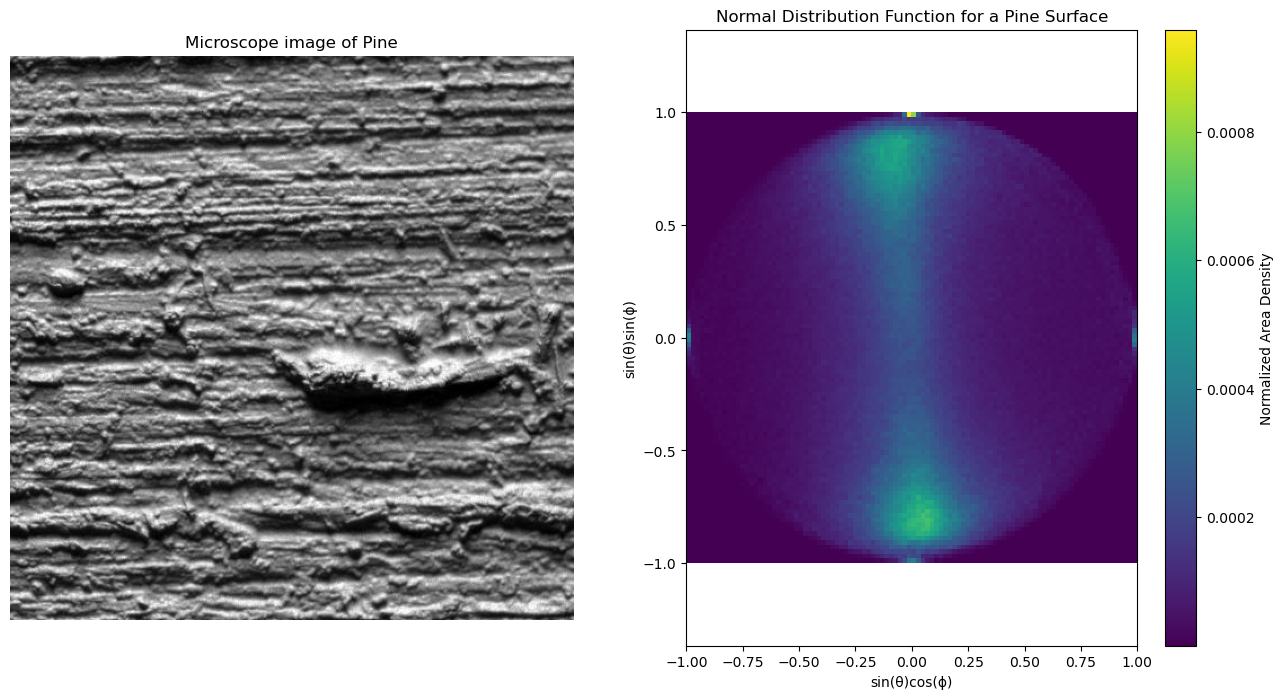

In [ ]:
OBJ_PATH = "pine.obj"  
img = plt.imread(f"pine.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Pine', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 45.81 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

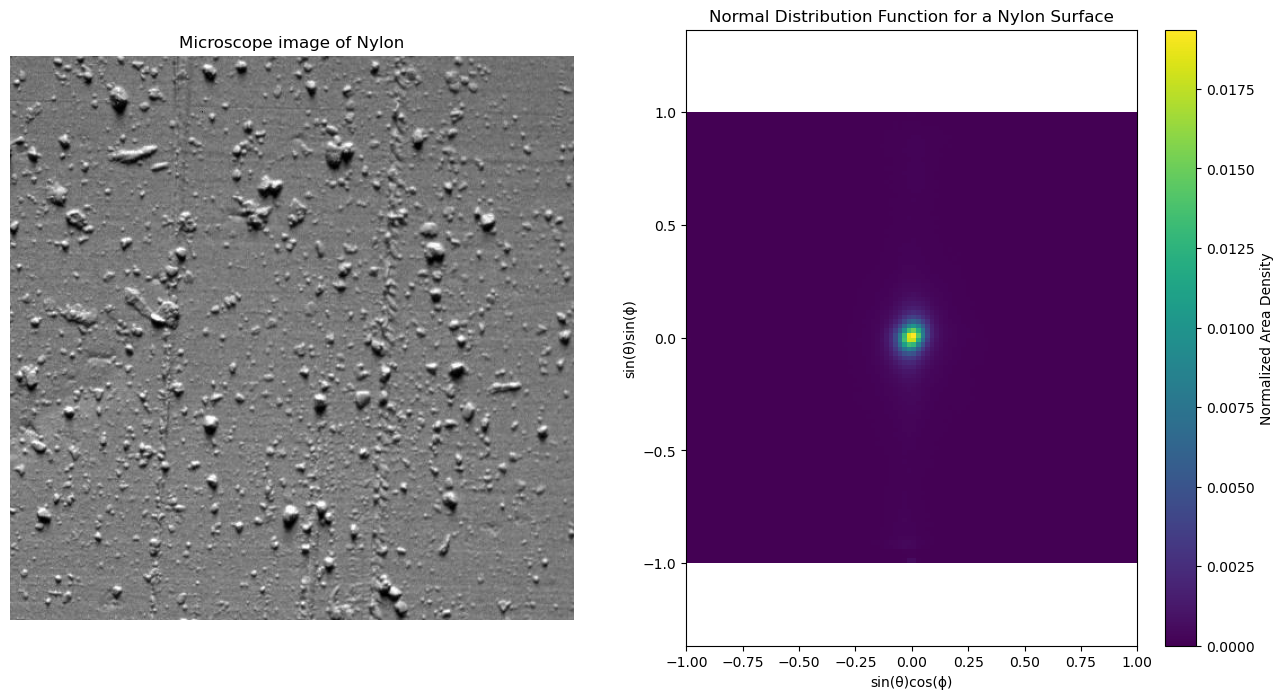

In [ ]:
OBJ_PATH = "nylon.obj"  
img = plt.imread(f"nylon.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Nylon', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 42.87 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

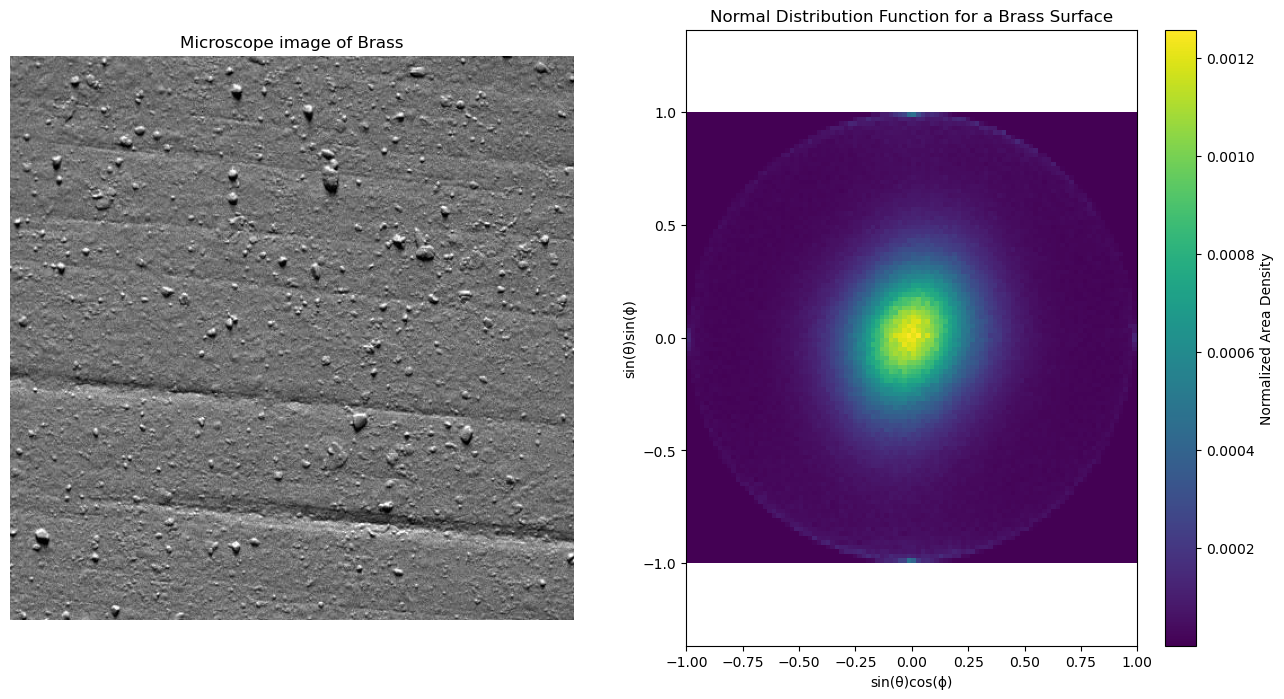

In [ ]:
OBJ_PATH = "brass.obj"  
img = plt.imread(f"brass.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Brass', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 58.28 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

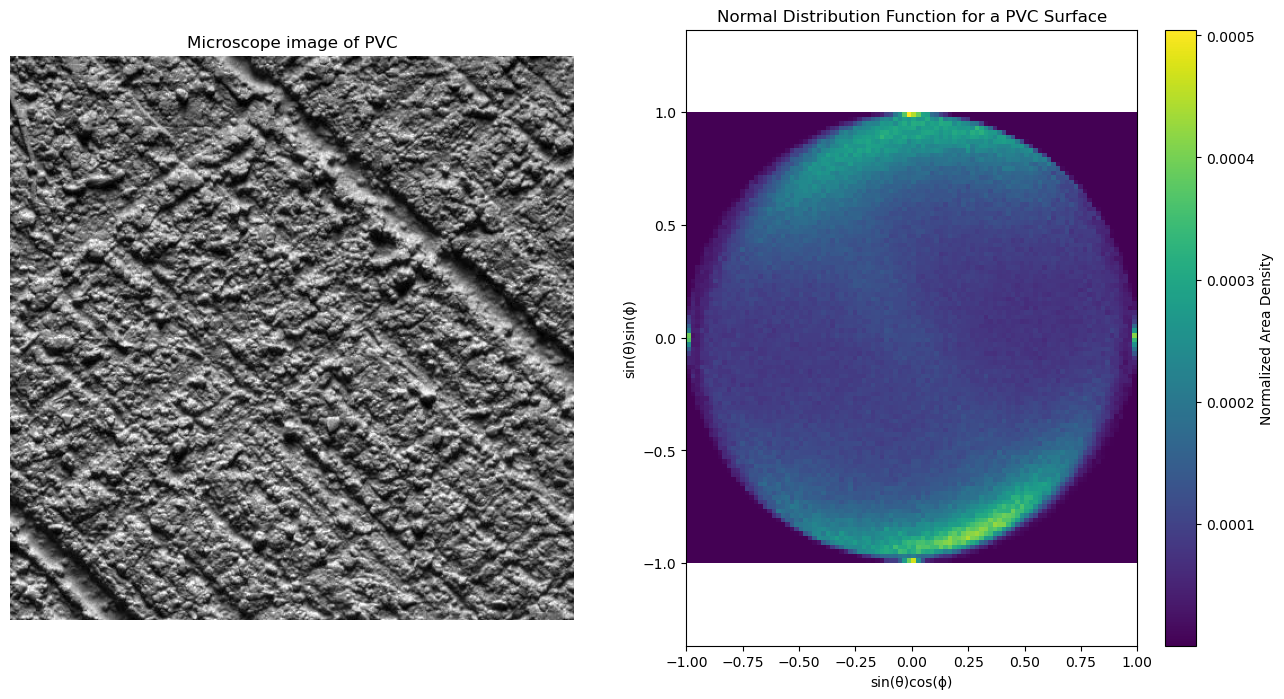

In [ ]:
OBJ_PATH = "pvc.obj"  
img = plt.imread(f"pvc.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'PVC', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 80.62 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

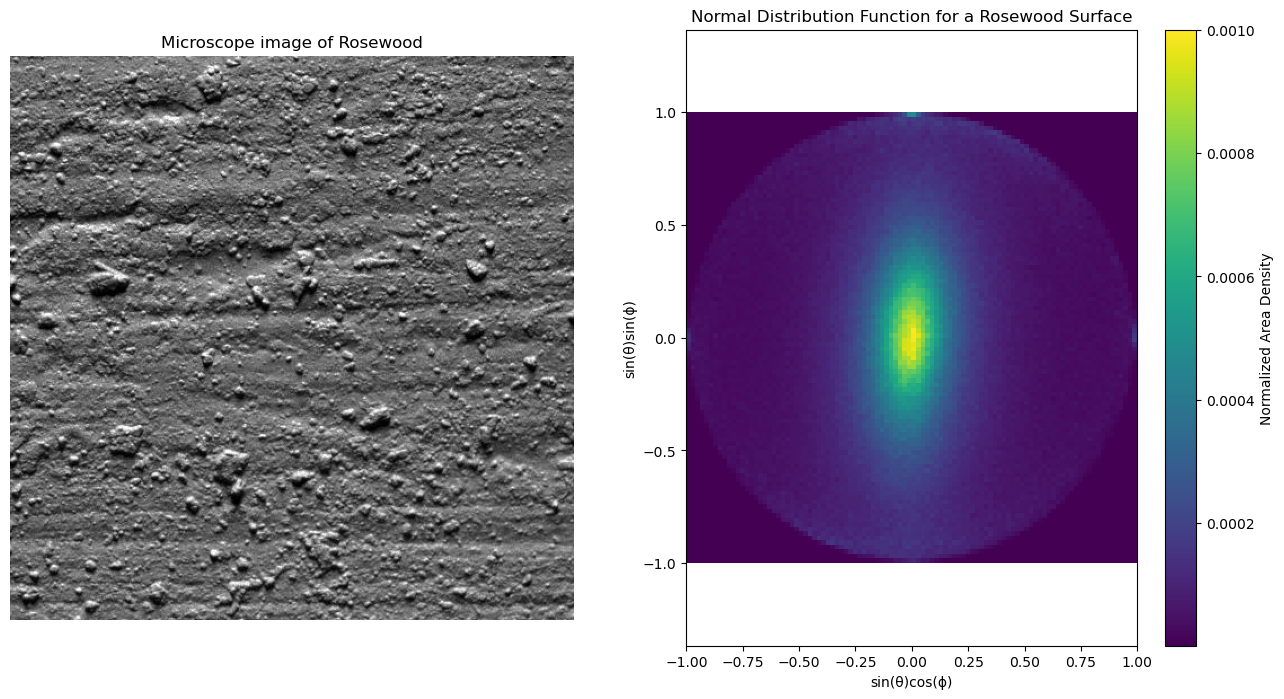

In [ ]:
OBJ_PATH = "rosewood.obj"  
img = plt.imread(f"rosewood.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Rosewood', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 96.32 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

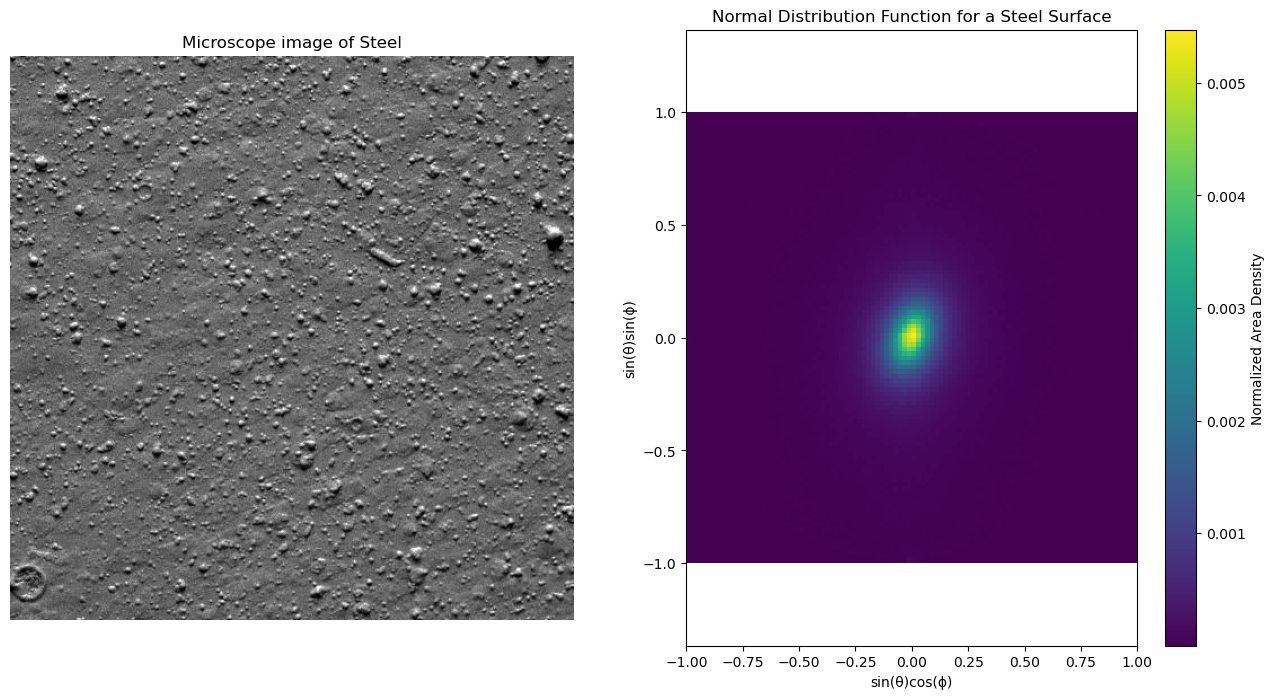

In [ ]:
OBJ_PATH = "steel.obj"  
img = plt.imread(f"steel.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Steel', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 42.80 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

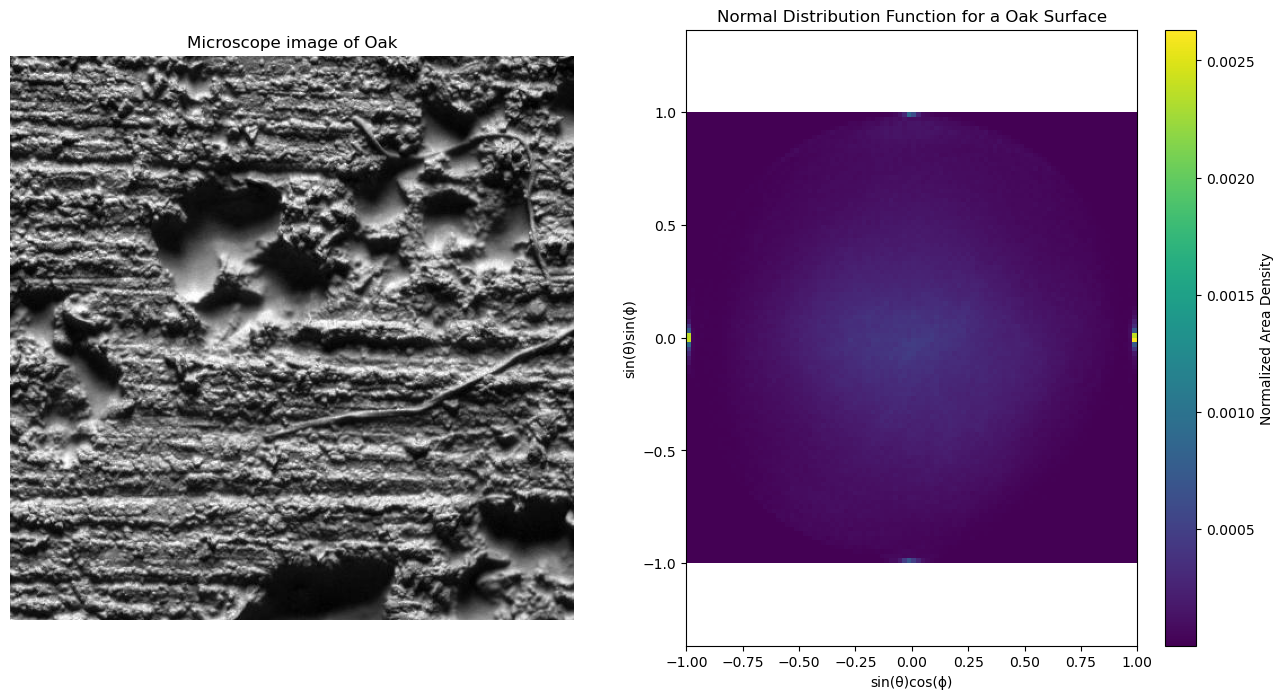

In [ ]:
OBJ_PATH = "oak.obj"  
img = plt.imread(f"oak.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Oak', img)

processing faces:   0.0% (0/1048576)
processing faces:   5.0% (52428/1048576)
processing faces:  10.0% (104856/1048576)
processing faces:  15.0% (157284/1048576)
processing faces:  20.0% (209712/1048576)
processing faces:  25.0% (262140/1048576)
processing faces:  30.0% (314568/1048576)
processing faces:  35.0% (366996/1048576)
processing faces:  40.0% (419424/1048576)
processing faces:  45.0% (471852/1048576)
processing faces:  50.0% (524280/1048576)
processing faces:  55.0% (576708/1048576)
processing faces:  60.0% (629136/1048576)
processing faces:  65.0% (681564/1048576)
processing faces:  70.0% (733992/1048576)
processing faces:  75.0% (786420/1048576)
processing faces:  80.0% (838848/1048576)
processing faces:  85.0% (891276/1048576)
processing faces:  90.0% (943704/1048576)
processing faces:  95.0% (996132/1048576)
processing faces: 100.0% (1048560/1048576)
OBJ parsing runtime: 42.93 seconds
processing faces: 100.0% (1048576/1048576)

Loaded OBJ: 1050625 vertices
Generated: 2097

<Figure size 1000x800 with 0 Axes>

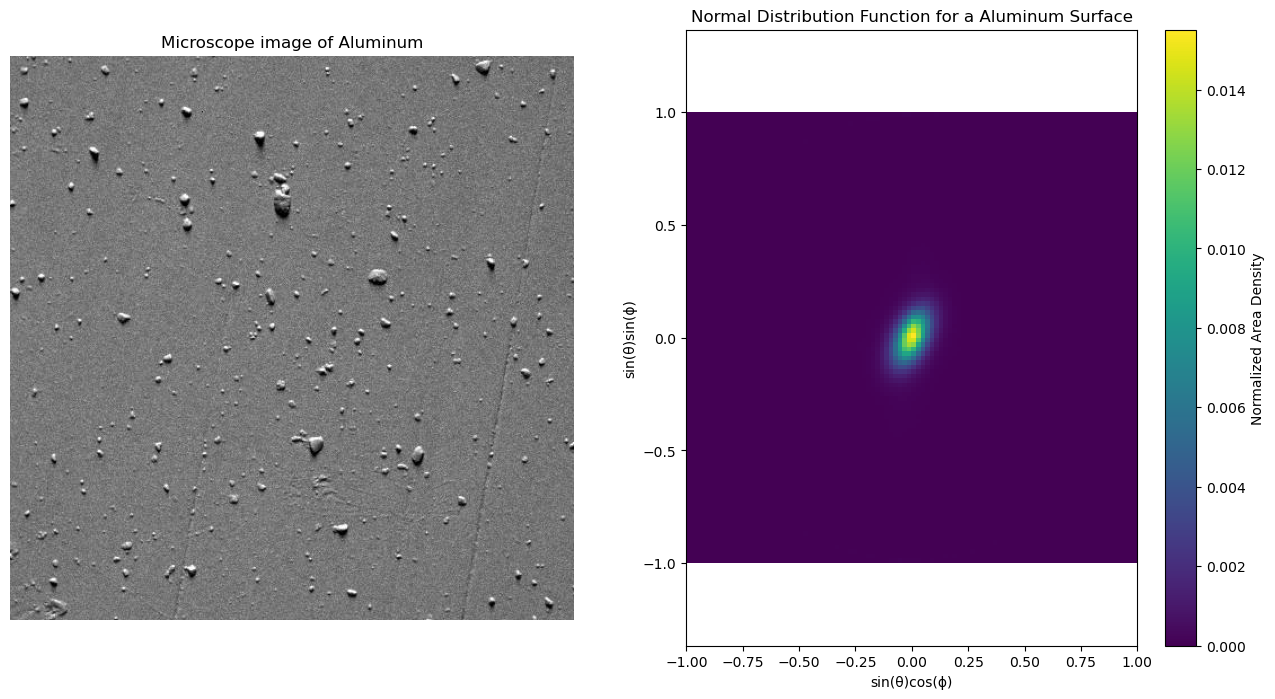

In [ ]:
OBJ_PATH = "aluminum.obj"  
img = plt.imread(f"aluminum.jpg")  # Load corresponding image
triangle_normals, triangle_areas = parse_obj(OBJ_PATH)
H, xedges, yedges = create_ndf_histogram_from_obj(triangle_normals, triangle_areas, 'Aluminum', img)

=== Friction Model Demonstration ===
Randomly sampling 10000 faces out of 1048576 total faces
processing faces:   0.0% (0/10000)
processing faces:   5.0% (500/10000)
processing faces:  10.0% (1000/10000)
processing faces:  15.0% (1500/10000)
processing faces:  20.0% (2000/10000)
processing faces:  25.0% (2500/10000)
processing faces:  30.0% (3000/10000)
processing faces:  35.0% (3500/10000)
processing faces:  40.0% (4000/10000)
processing faces:  45.0% (4500/10000)
processing faces:  50.0% (5000/10000)
processing faces:  55.0% (5500/10000)
processing faces:  60.0% (6000/10000)
processing faces:  65.0% (6500/10000)
processing faces:  70.0% (7000/10000)
processing faces:  75.0% (7500/10000)
processing faces:  80.0% (8000/10000)
processing faces:  85.0% (8500/10000)
processing faces:  90.0% (9000/10000)
processing faces:  95.0% (9500/10000)
OBJ parsing runtime: 3.73 seconds
processing faces: 100.0% (10000/10000)

Loaded OBJ: 1050625 vertices
Generated: 20000 triangle faces from 10000 samp

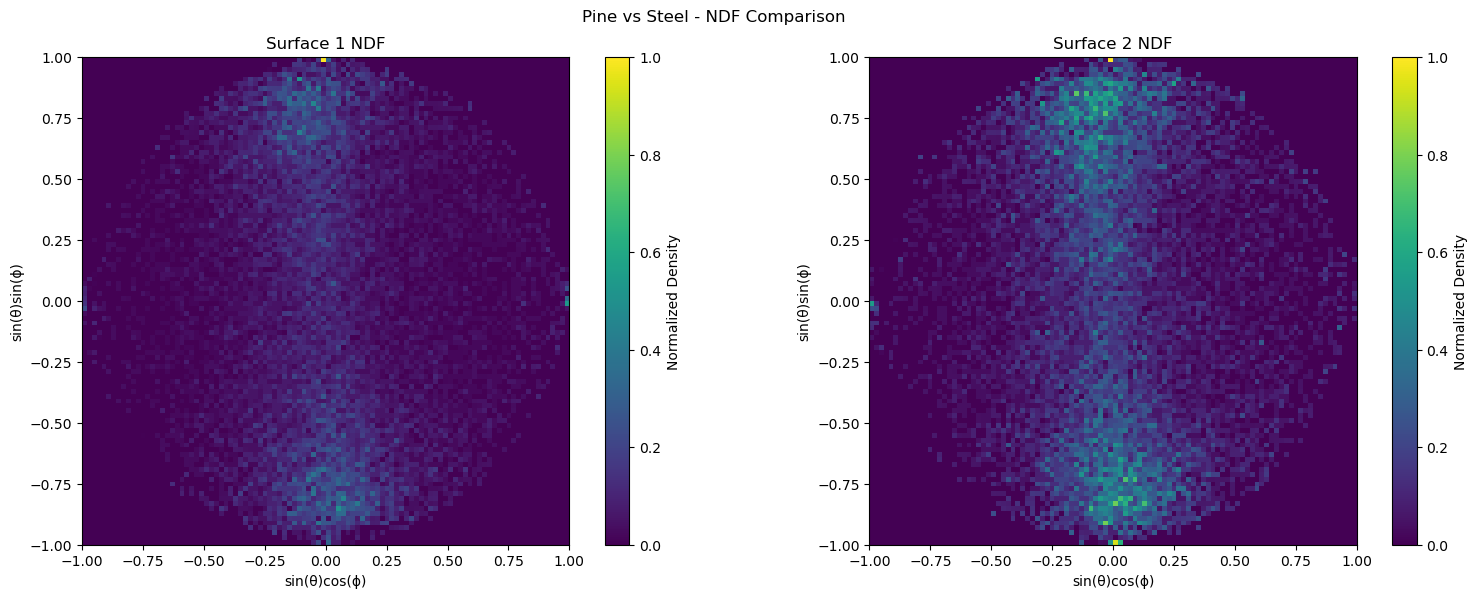

Friction Statistics:
  Max μ: 0.0496
  Min μ: 0.0028
  Mean μ: 0.0107
  Anisotropy ratio: 18.03


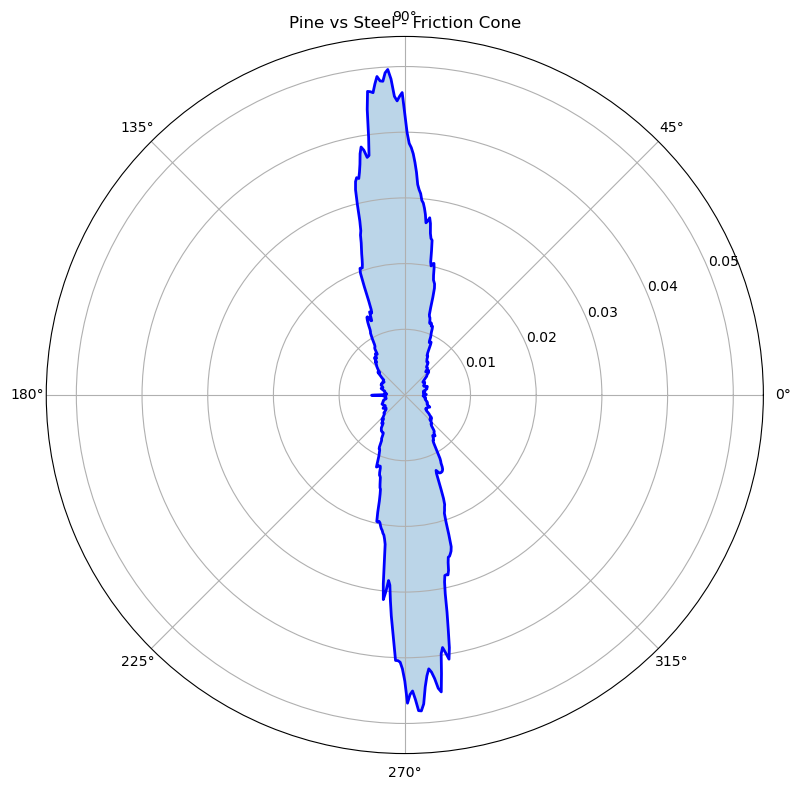


Friction coefficient at 45°: 0.0050


In [24]:
# Friction model using NDF slide+integrate overlap, with PEAK (L∞) normalization
# Based on JavaScript implementation from friction.js
# 
# What this class does:
#   Converts micro-normal samples from two contacting surfaces into 2D 
#   normal-distribution functions (NDFs), then estimates a direction-dependent
#   friction coefficient μ(u) by integrating the overlap of those NDFs along a
#   chord oriented at direction u. The result is scaled by load and material factors.

class Friction:
    def __init__(self, surface1_data, surface2_data, k=1.0):
        """
        Initialize friction model with two surfaces
        
        Args:
            surface1_data: Dict with 'ndf_samples' and 'area_weights' for surface 1
            surface2_data: Dict with 'ndf_samples' and 'area_weights' for surface 2
            k: Material friction coefficient scaling factor
        """
        # Surface data
        self.surface1_data = surface1_data
        self.surface2_data = surface2_data
        
        # Parameters (matching JavaScript defaults)
        self.k = k
        self.bins = 100
        self.FN = 1.0  # Normal force
        self.Fref = 1.0  # Reference force
        self.alpha = 0.5  # Load scaling exponent
        self.M = 1.0  # Material factor
        self.dTheta = 0.0  # Angular offset
        self.taps = 256  # Number of integration samples
        self.num_dirs = 360*2  # Number of directional samples
        
        # Build NDF grids with peak normalization
        self.ndf_grid1 = self._build_grid(
            surface1_data['ndf_samples'], 
            surface1_data['area_weights'], 
            self.bins
        )
        self.ndf_grid2 = self._build_grid(
            surface2_data['ndf_samples'], 
            surface2_data['area_weights'], 
            self.bins
        )
        
        # Calculate load scaling factor
        self.load_scaling = (
            np.power(self.FN / self.Fref, self.alpha) if self.Fref > 0 else 1.0
        )
        
        # Cache directional profile
        self.directional_profile_cache = self.directional_profile()
    
    def directional_profile(self):
        """
        Calculate friction coefficient in all directions
        
        Returns:
            Dict with 'angles' and 'mus' arrays
        """
        angles = np.linspace(0, 2*np.pi, self.num_dirs, endpoint=False)
        mus = np.zeros(self.num_dirs)
        
        for i, angle in enumerate(angles):
            mus[i] = self.k * self._overlap_1d(angle, self.taps) * self.load_scaling
        
        self.directional_profile_cache = {'angles': angles, 'mus': mus}
        return self.directional_profile_cache
    
    def get_mu_at_angle(self, angle):
        """
        Get friction coefficient at a specific angle
        
        Args:
            angle: Angle in radians
            
        Returns:
            Friction coefficient mu at the given angle
        """
        if self.directional_profile_cache is None:
            self.directional_profile()
        
        # Normalize angle to [0, 2π) range
        normalized_angle = ((angle % (2 * np.pi)) + 2 * np.pi) % (2 * np.pi)
        
        # Find closest index
        index = int(np.floor((normalized_angle / (2 * np.pi)) * len(self.directional_profile_cache['angles'])))
        index = np.clip(index, 0, len(self.directional_profile_cache['mus']) - 1)
        
        return self.directional_profile_cache['mus'][index]
    
    def _build_grid(self, samples, weights, bins):
        """
        Build a normalized 2D grid from sample points and weights within a unit disk.
        
        Args:
            samples: Array of sample points with x,y coordinates (Nx2)
            weights: Array of weights for each sample (N,) or None
            bins: Number of bins per dimension
            
        Returns:
            Normalized grid of size bins×bins
        """
        grid = np.zeros((bins, bins), dtype=np.float32)
        bin_size = 2.0 / bins
        
        # Convert samples to numpy array if needed
        if not isinstance(samples, np.ndarray):
            samples = np.array(samples)
        
        # Accumulate sample weights into bins (ignore samples outside unit disk)
        for i in range(len(samples)):
            x, y = samples[i, 0], samples[i, 1]
            w = weights[i] if weights is not None else 1.0
            
            # Skip samples outside unit disk
            if x*x + y*y > 1.0:
                continue
            
            # Convert to bin coordinates
            bx = int(np.floor((x + 1.0) / bin_size))
            by = int(np.floor((y + 1.0) / bin_size))
            
            # Check bounds
            if bx < 0 or bx >= bins or by < 0 or by >= bins:
                continue
            
            grid[by, bx] += w
        
        # PEAK (L∞) normalization: max value becomes 1 (if nonzero)
        max_val = np.max(grid)
        if max_val > 0:
            grid = grid / max_val
        
        return grid
    
    def _rotate_grid_90(self, grid):
        """
        Rotate a 2D grid by 90 degrees clockwise.
        
        Args:
            grid: 2D array to rotate
            
        Returns:
            Rotated 2D array
        """
        return np.rot90(grid, k=-1)
    
    def _sample_grid(self, grid, bins, x, y):
        """
        Bilinear interpolation from a grid at (x,y) ∈ [-1,1]^2.
        Returns 0 outside unit disk.
        
        Args:
            grid: 2D array to sample from
            bins: Number of bins per dimension
            x, y: Coordinates to sample at
            
        Returns:
            Interpolated value
        """
        if x*x + y*y > 1.0:
            return 0.0  # Outside disk → no contribution
        
        # Map [-1,1] → [0, bins-1]
        u = (x + 1.0) * 0.5 * (bins - 1)
        v = (y + 1.0) * 0.5 * (bins - 1)
        
        x0, y0 = int(np.floor(u)), int(np.floor(v))
        x1, y1 = min(x0 + 1, bins - 1), min(y0 + 1, bins - 1)
        
        tx, ty = u - x0, v - y0
        
        # Bilinear interpolation
        c00 = grid[y0, x0]
        c10 = grid[y0, x1]
        c01 = grid[y1, x0]
        c11 = grid[y1, x1]
        
        c0 = c00 * (1 - tx) + c10 * tx
        c1 = c01 * (1 - tx) + c11 * tx
        
        return c0 * (1 - ty) + c1 * ty
    
    def _overlap_1d(self, u_angle, taps):
        """
        1D overlap integral along direction u_angle.
        Evaluates numerically: ∫_{t=-1}^{1} f1(t·u) · f2(-t·u) dt
        
        Args:
            u_angle: The angle (in radians) defining the integration direction
            taps: The number of sample points for numerical integration
            
        Returns:
            The computed overlap integral value
        """
        g1 = self.ndf_grid1
        g2 = self.ndf_grid2
        bins = self.bins
        
        # Direction from angle
        ux = np.cos(u_angle)
        uy = np.sin(u_angle)
        
        t_max = 1.0  # integration from -1 to 1
        dt = (2 * t_max) / max(1, taps - 1)
        
        total = 0.0
        for i in range(taps):
            t = -t_max + i * dt
            
            # Surface 1: along +u
            x1 = t * ux
            y1 = t * uy
            
            # Surface 2: mirrored along -u
            x2 = -t * ux
            y2 = -t * uy
            
            f1 = self._sample_grid(g1, bins, x1, y1)
            f2 = self._sample_grid(g2, bins, x2, y2)
            
            # Weighting: more weight for t<0, less for t>0
            weight = 1.0 - t
            
            total += weight * f1 * f2
        
        return total * dt
    
    def plot_directional_friction(self, title="Directional Friction Profile"):
        """
        Plot the directional friction coefficient profile
        
        Args:
            title: Title for the plot
        """
        profile = self.directional_profile_cache
        if profile is None:
            profile = self.directional_profile()
        
        angles = profile['angles']
        mus = profile['mus']
        
        # Create polar plot
        fig, ax = plt.subplots(subplot_kw=dict(projection='polar'), figsize=(10, 8))
        ax.plot(angles, mus, 'b-', linewidth=2)
        ax.fill(angles, mus, alpha=0.3)
        ax.set_title(title)
        ax.set_ylim(0, max(mus) * 1.1)
        ax.grid(True)
        
        # Add statistics
        max_mu = np.max(mus)
        min_mu = np.min(mus)
        mean_mu = np.mean(mus)
        
        print(f"Friction Statistics:")
        print(f"  Max μ: {max_mu:.4f}")
        print(f"  Min μ: {min_mu:.4f}")
        print(f"  Mean μ: {mean_mu:.4f}")
        print(f"  Anisotropy ratio: {max_mu/min_mu:.2f}")
        
        plt.tight_layout()
        plt.show()
        
        return fig, ax
    
    def plot_ndf_grids(self, title="NDF Grids"):
        """
        Plot the two NDF grids side by side
        
        Args:
            title: Title for the plot
        """
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Plot grid 1
        im1 = ax1.imshow(self.ndf_grid1, extent=[-1, 1, -1, 1], origin='lower', cmap='viridis')
        ax1.set_title('Surface 1 NDF')
        ax1.set_xlabel("sin(θ)cos(ϕ)")
        ax1.set_ylabel("sin(θ)sin(ϕ)")
        plt.colorbar(im1, ax=ax1, label='Normalized Density')
        
        # Plot grid 2
        im2 = ax2.imshow(self.ndf_grid2, extent=[-1, 1, -1, 1], origin='lower', cmap='viridis')
        ax2.set_title('Surface 2 NDF')
        ax2.set_xlabel("sin(θ)cos(ϕ)")
        ax2.set_ylabel("sin(θ)sin(ϕ)")
        plt.colorbar(im2, ax=ax2, label='Normalized Density')
        
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()
        
        return fig, (ax1, ax2)


def create_surface_data_from_obj(obj_path, sample_size=10000):
    """
    Helper function to create surface data dictionary from OBJ file
    
    Args:
        obj_path: Path to OBJ file
        sample_size: Optional sample size for large meshes
        
    Returns:
        Dictionary with 'ndf_samples' and 'area_weights'
    """
    if sample_size is not None:
        triangle_normals, triangle_areas = parse_obj_sampled(obj_path, sample_size)
    else:
        triangle_normals, triangle_areas = parse_obj(obj_path)
    
    # Filter out normals with negative z values
    valid_mask = triangle_normals[:, 2] >= 0
    filtered_normals = triangle_normals[valid_mask]
    filtered_areas = triangle_areas[valid_mask]
    
    # Convert to NDF coordinates
    x, y = normals_to_ndf_xy(filtered_normals)
    ndf_samples = np.column_stack([x, y])
    
    return {
        'ndf_samples': ndf_samples,
        'area_weights': filtered_areas
    }


# Example usage:
# Create friction model between two surfaces
def demo_friction_calculation():
    """
    Demonstration of friction calculation between two surfaces
    """
    print("=== Friction Model Demonstration ===")
    
    # Example with two different surfaces
    surface1_data = create_surface_data_from_obj("pine.obj")
    surface2_data = create_surface_data_from_obj("pine.obj")
    
    # Create friction model
    friction_model = Friction(surface1_data, surface2_data, k=0.5)
    
    # Plot NDF grids
    friction_model.plot_ndf_grids("Pine vs Steel - NDF Comparison")
    
    # Plot directional friction profile
    friction_model.plot_directional_friction("Pine vs Steel - Friction Cone")
    
    # Test specific angle
    angle_test = np.pi / 4  # 45 degrees
    mu_at_45 = friction_model.get_mu_at_angle(angle_test)
    print(f"\nFriction coefficient at 45°: {mu_at_45:.4f}")
    
    return friction_model

# Uncomment to run demo:
friction_model = demo_friction_calculation()